# Latent Space Analysis for GRASSY Model

This notebook analyzes whether the latent space learned by the GRASSY model is well-organized.

We use multiple visualization techniques including:
- **PHATE** (Potential of Heat-diffusion for Affinity-based Transition Embedding)
- **PCA** (Principal Component Analysis)

We also compute quantitative metrics to assess the organization of the latent space.

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Optional imports - install if needed
try:
    import phate
    PHATE_AVAILABLE = True
except ImportError:
    print("PHATE not installed. Install with: pip install phate")
    PHATE_AVAILABLE = False

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("Setup complete!")
print(f"PHATE available: {PHATE_AVAILABLE}")

Setup complete!
PHATE available: True


## 2. Load Data

Configure the paths to your training output directory below.

In [4]:
# ============================================
# CONFIGURE YOUR PATHS HERE
# ============================================

# Path to your training output directory
TRAINING_OUTPUT_DIR = "../outputs/MOSES_12K_e2e_regress_nokld_2026-01-21-18-20-29" 

# Or specify individual file paths
EMBEDDING_FILE = None  # e.g., "ordered_embedding_ZINC_regress_kld.npy"
PROPERTIES_FILE = None  # e.g., "embedding_prop_lists_ZINC_regress_kld.npy"
SCATTERING_FILE = None  # e.g., "scattering_coeffs_ZINC_regress_kld.npy"
ATOM_PERCENTAGES_FILE = None  # e.g., "atom_percentages_ZINC_regress_kld.npy"

In [5]:
def find_files(directory):
    """Auto-detect output files from training directory."""
    files = {}
    if os.path.exists(directory):
        for f in os.listdir(directory):
            if f.endswith('.npy'):
                if 'ordered_embedding' in f:
                    files['embedding'] = os.path.join(directory, f)
                elif 'embedding_prop_lists' in f:
                    files['properties'] = os.path.join(directory, f)
                elif 'scattering_coeffs' in f:
                    files['scattering'] = os.path.join(directory, f)
                elif 'atom_percentages' in f:
                    files['atom_percentages'] = os.path.join(directory, f)
    return files

# Auto-detect files
detected_files = find_files(TRAINING_OUTPUT_DIR)
print("Detected files:")
for k, v in detected_files.items():
    print(f"  {k}: {v}")

Detected files:
  atom_percentages: ../outputs/MOSES_12K_e2e_regress_nokld_2026-01-21-18-20-29/atom_percentages_MOSES_12K_e2e.npy
  properties: ../outputs/MOSES_12K_e2e_regress_nokld_2026-01-21-18-20-29/embedding_prop_lists_MOSES_12K_e2e.npy
  embedding: ../outputs/MOSES_12K_e2e_regress_nokld_2026-01-21-18-20-29/ordered_embedding_MOSES_12K_e2e.npy
  scattering: ../outputs/MOSES_12K_e2e_regress_nokld_2026-01-21-18-20-29/scattering_coeffs_MOSES_12K_e2e.npy


In [6]:
# Load embeddings
embedding_path = EMBEDDING_FILE or detected_files.get('embedding')
if embedding_path and os.path.exists(embedding_path):
    embeddings = np.load(embedding_path)
    print(f"Loaded embeddings: {embeddings.shape}")
else:
    raise FileNotFoundError(f"Embedding file not found: {embedding_path}")

# Load properties
properties_path = PROPERTIES_FILE or detected_files.get('properties')
if properties_path and os.path.exists(properties_path):
    properties = np.load(properties_path, allow_pickle=True)
    # Convert to numpy array with proper shape
    if isinstance(properties, np.ndarray) and properties.dtype == object:
        properties = np.array([np.array(p) for p in properties])
    print(f"Loaded properties: {properties.shape}")
else:
    properties = None
    print("Properties file not found - will use synthetic coloring")

# Load scattering coefficients (optional)
scattering_path = SCATTERING_FILE or detected_files.get('scattering')
if scattering_path and os.path.exists(scattering_path):
    scattering_coeffs = np.load(scattering_path)
    print(f"Loaded scattering coefficients: {scattering_coeffs.shape}")
else:
    scattering_coeffs = None
    print("Scattering coefficients not found")

# Load atom percentages (optional)
atom_path = ATOM_PERCENTAGES_FILE or detected_files.get('atom_percentages')
if atom_path and os.path.exists(atom_path):
    atom_percentages = np.load(atom_path, allow_pickle=True)
    print(f"Loaded atom percentages: {atom_percentages.shape}")
else:
    atom_percentages = None
    print("Atom percentages not found")

Loaded embeddings: (12000, 25)
Loaded properties: (8, 12000)
Loaded scattering coefficients: (12000, 308)
Loaded atom percentages: (3, 12000)


## 3. Prepare Property Labels for Coloring

In [7]:
# Define property names (customize based on your dataset)
PROPERTY_NAMES = [
    'Property 1',
    'Property 2', 
    'Property 3',
    # Add more as needed
]

# Prepare property arrays for visualization
if properties is not None:
    # Handle different property array formats
    if properties.ndim == 1:
        # List of property lists
        prop_arrays = [np.array(p) for p in properties]
        n_properties = len(prop_arrays)
    elif properties.ndim == 2:
        # Check orientation
        if properties.shape[0] == embeddings.shape[0]:
            # Shape: (n_samples, n_properties)
            prop_arrays = [properties[:, i] for i in range(properties.shape[1])]
        else:
            # Shape: (n_properties, n_samples)
            prop_arrays = [properties[i, :] for i in range(properties.shape[0])]
        n_properties = len(prop_arrays)
    else:
        prop_arrays = []
        n_properties = 0
    
    # Update property names if needed
    while len(PROPERTY_NAMES) < n_properties:
        PROPERTY_NAMES.append(f'Property {len(PROPERTY_NAMES) + 1}')
    
    print(f"Number of properties: {n_properties}")
    for i, prop in enumerate(prop_arrays):
        print(f"  {PROPERTY_NAMES[i]}: shape={np.array(prop).shape}, " 
              f"range=[{np.min(prop):.4f}, {np.max(prop):.4f}]")
else:
    prop_arrays = []
    n_properties = 0
    print("No properties available")

Number of properties: 8
  Property 1: shape=(12000,), range=[0.2934, 0.2934]
  Property 2: shape=(12000,), range=[0.3864, 0.3864]
  Property 3: shape=(12000,), range=[0.4100, 0.4100]
  Property 4: shape=(12000,), range=[-0.4232, -0.4232]
  Property 5: shape=(12000,), range=[-1.5747, -1.5747]
  Property 6: shape=(12000,), range=[1.0523, 1.0523]
  Property 7: shape=(12000,), range=[0.5217, 0.5217]
  Property 8: shape=(12000,), range=[1.1683, 1.1683]


## 4. Dimensionality Reduction Methods

In [8]:
# Standardize embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Scaled embeddings: mean={embeddings_scaled.mean():.6f}, std={embeddings_scaled.std():.6f}")

Embeddings shape: (12000, 25)
Scaled embeddings: mean=-0.000000, std=1.000000


### 4.1 PCA

In [9]:
print("Computing PCA...")
pca = PCA(n_components=min(50, embeddings.shape[1]))
embeddings_pca_full = pca.fit_transform(embeddings_scaled)
embeddings_pca = embeddings_pca_full[:, :2]

print(f"PCA explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")
print(f"Cumulative variance explained by 2 components: {pca.explained_variance_ratio_[:2].sum():.4f}")
print(f"Cumulative variance explained by 10 components: {pca.explained_variance_ratio_[:10].sum():.4f}")

Computing PCA...
PCA explained variance ratio (first 10 components): [0.15963255 0.13062575 0.11976711 0.11083816 0.07673504 0.07367294
 0.06241398 0.04402017 0.04021391 0.03511104]
Cumulative variance explained by 2 components: 0.2903
Cumulative variance explained by 10 components: 0.8530


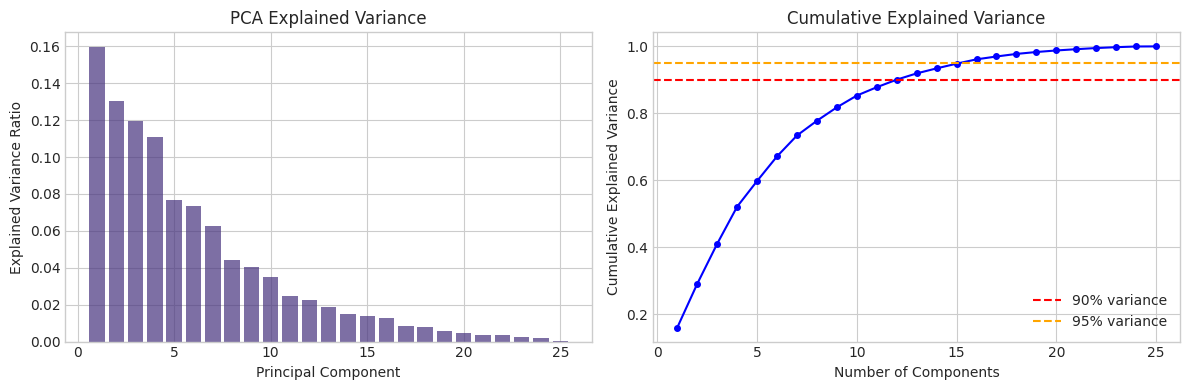

In [10]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Explained Variance')

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'b-o', markersize=4)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.2 PHATE

In [11]:
# PHATE hyperparameters to explore
PHATE_KNN = 5  # Number of nearest neighbors
PHATE_DECAY = 40  # Decay parameter (controls locality)
PHATE_T = 'auto'  # Diffusion time (auto or integer)

if PHATE_AVAILABLE:
    print(f"Computing PHATE (knn={PHATE_KNN}, decay={PHATE_DECAY})...")
    phate_op = phate.PHATE(
        n_components=2,
        knn=PHATE_KNN,
        decay=PHATE_DECAY,
        t=PHATE_T,
        verbose=True,
        random_state=42
    )
    embeddings_phate = phate_op.fit_transform(embeddings_scaled)
    print("PHATE complete!")
else:
    embeddings_phate = None
    print("PHATE not available")

Computing PHATE (knn=5, decay=40)...
Calculating PHATE...
  Running PHATE on 12000 observations and 25 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 3.04 seconds.
    Calculating affinities...
    Calculated affinities in 0.14 seconds.
  Calculated graph and diffusion operator in 3.19 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 20.50 seconds.
    Calculating KMeans...
    Calculated KMeans in 9.10 seconds.
  Calculated landmark operator in 29.61 seconds.
  Calculating optimal t...
    Automatically selected t = 23
  Calculated optimal t in 87.39 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 1.52 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 3.18 seconds.
Calculated PHATE in 125.32 secon

## 5. Visualization Functions

In [12]:
def plot_embedding_comparison(embeddings_dict, colors, color_label="Property", 
                               figsize=(16, 4), s=5, cmap='viridis', alpha=0.7):
    """
    Plot multiple embedding visualizations side by side.
    
    Parameters:
    -----------
    embeddings_dict : dict
        Dictionary mapping method names to 2D embeddings
    colors : array-like
        Values to color points by
    color_label : str
        Label for the colorbar
    """
    n_plots = len(embeddings_dict)
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]
    
    for ax, (name, emb) in zip(axes, embeddings_dict.items()):
        if emb is None:
            ax.text(0.5, 0.5, f'{name}\nNot Available', 
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(name)
            continue
            
        sc = ax.scatter(emb[:, 0], emb[:, 1], c=colors, s=s, 
                       cmap=cmap, alpha=alpha, rasterized=True)
        ax.set_title(name)
        ax.set_xlabel('Dimension 1')
        ax.set_ylabel('Dimension 2')
        plt.colorbar(sc, ax=ax, label=color_label)
    
    plt.tight_layout()
    return fig


def plot_single_embedding(embedding, colors, title="Embedding", color_label="Value",
                          figsize=(8, 6), s=10, cmap='viridis', alpha=0.7):
    """
    Plot a single 2D embedding visualization.
    """
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=s, 
                   cmap=cmap, alpha=alpha, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    plt.colorbar(sc, ax=ax, label=color_label)
    plt.tight_layout()
    return fig

## 6. Visualizations Colored by Properties

In [13]:
# Collect all available embeddings
all_embeddings = {
    'PCA': embeddings_pca,
    'PHATE': embeddings_phate,
}

# Filter out None values
available_embeddings = {k: v for k, v in all_embeddings.items() if v is not None}
print(f"Available methods: {list(available_embeddings.keys())}")

Available methods: ['PCA', 'PHATE']



=== Property 1 ===


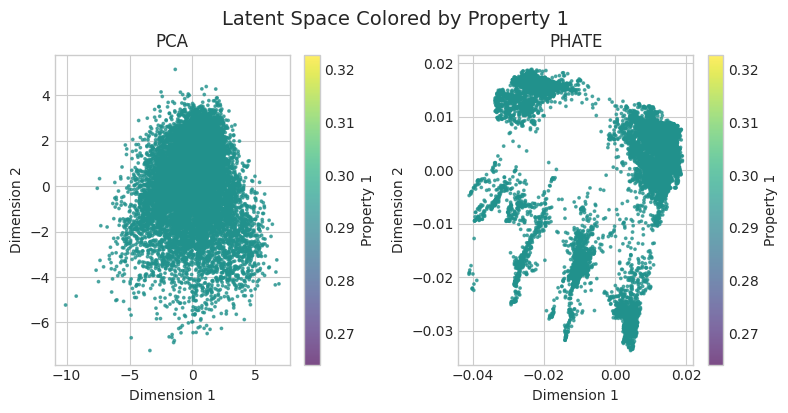


=== Property 2 ===


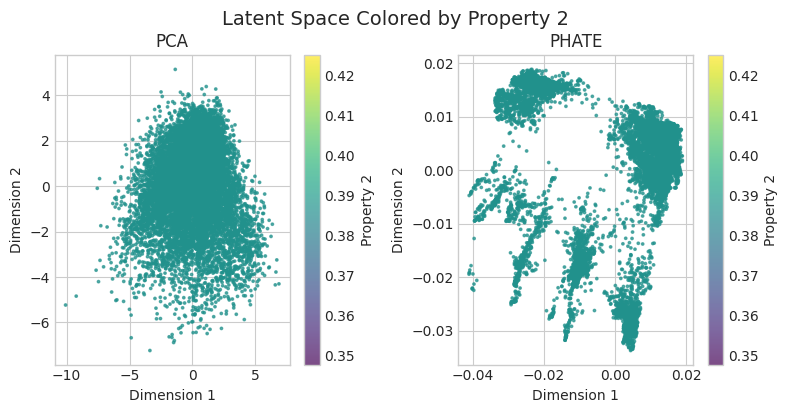


=== Property 3 ===


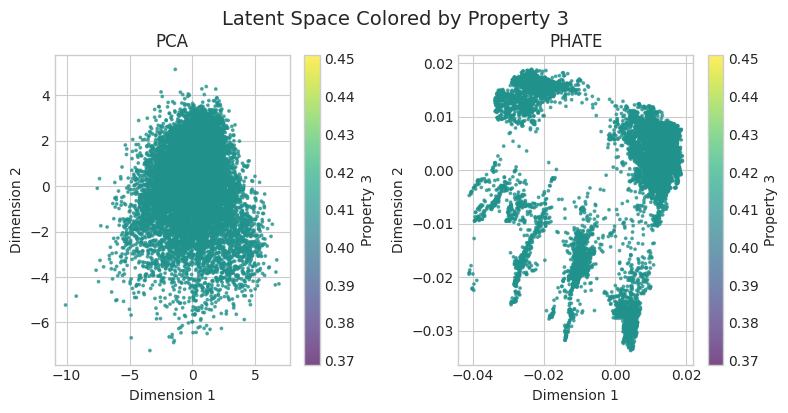


=== Property 4 ===


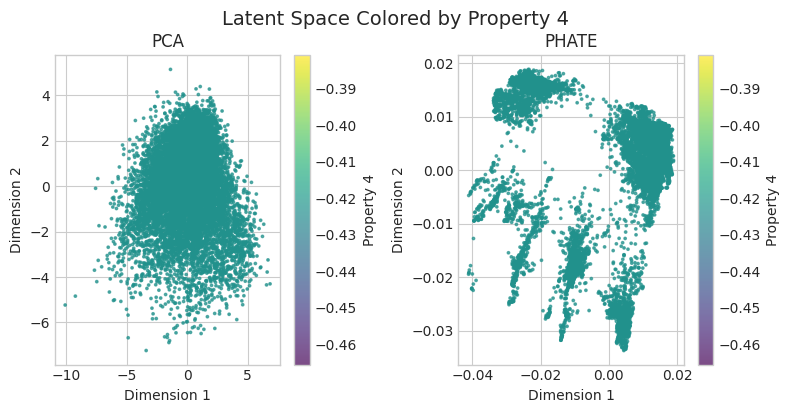


=== Property 5 ===


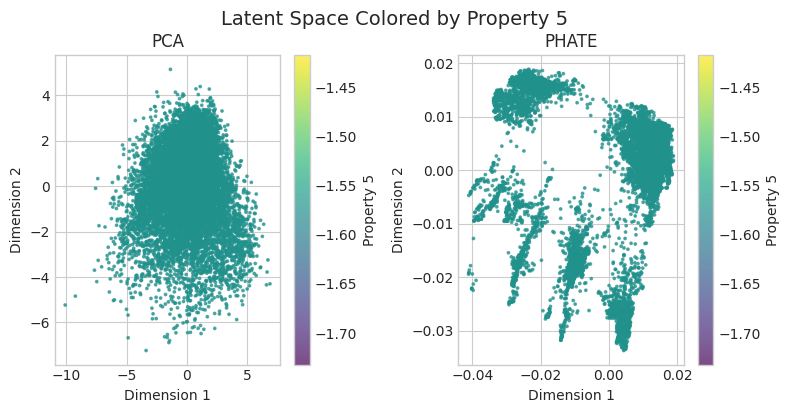


=== Property 6 ===


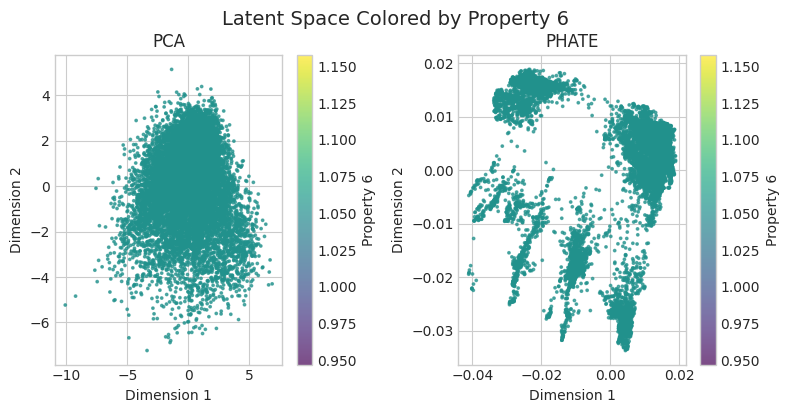


=== Property 7 ===


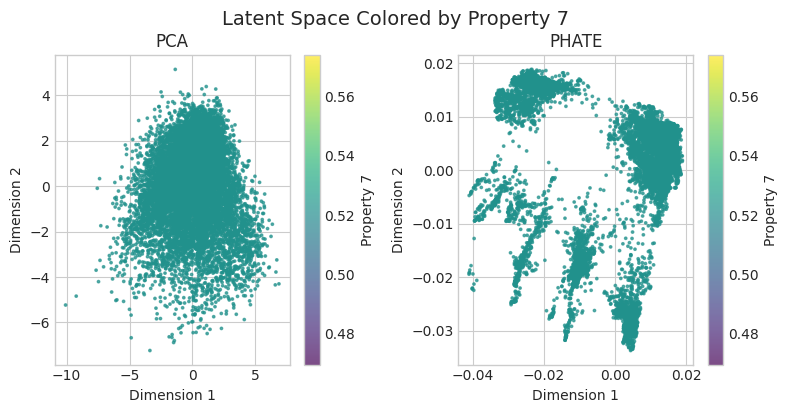


=== Property 8 ===


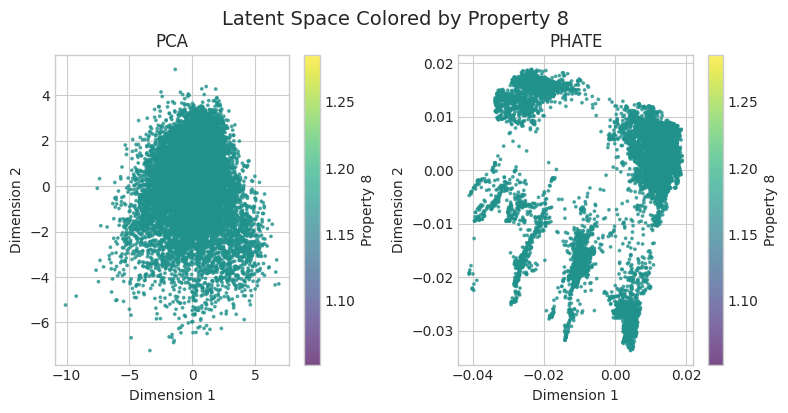

In [14]:
# Plot all methods colored by each property
if len(prop_arrays) > 0:
    for i, prop in enumerate(prop_arrays):
        prop_name = PROPERTY_NAMES[i] if i < len(PROPERTY_NAMES) else f'Property {i+1}'
        print(f"\n=== {prop_name} ===")
        
        fig = plot_embedding_comparison(
            available_embeddings,
            colors=prop,
            color_label=prop_name,
            figsize=(4*len(available_embeddings), 4),
            s=3
        )
        plt.suptitle(f'Latent Space Colored by {prop_name}', y=1.02, fontsize=14)
        plt.show()
else:
    # Plot without coloring
    fig = plot_embedding_comparison(
        available_embeddings,
        colors=np.arange(len(embeddings)),
        color_label='Sample Index',
        figsize=(4*len(available_embeddings), 4),
        s=3
    )
    plt.suptitle('Latent Space (No Properties Available)', y=1.02, fontsize=14)
    plt.show()

## 10. Atom Type Coloring (if available)

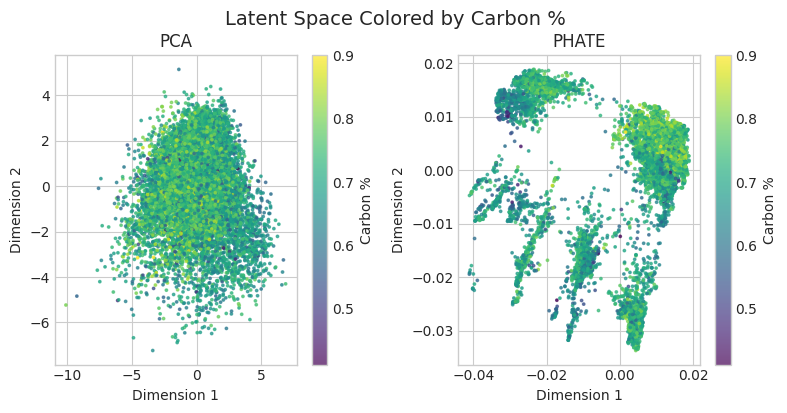

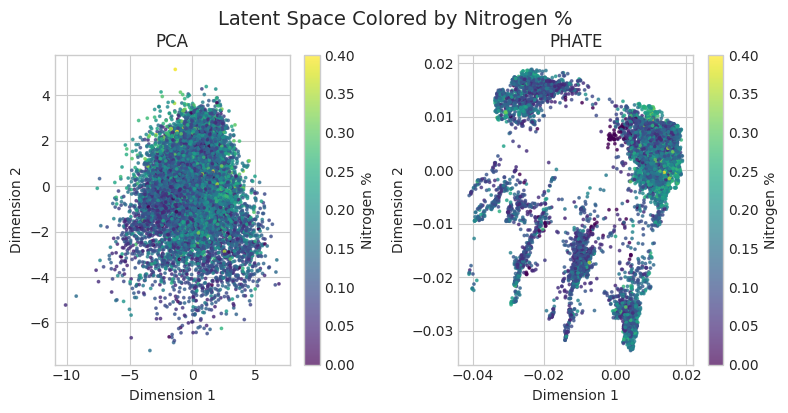

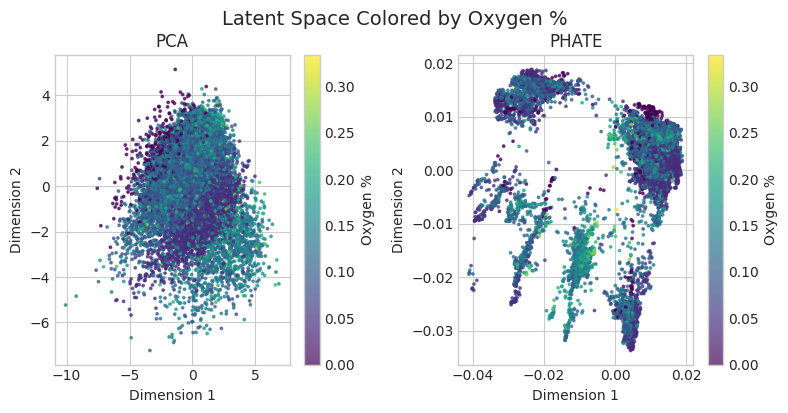

In [17]:
if atom_percentages is not None:
    atom_names = ['Carbon %', 'Nitrogen %', 'Oxygen %']
    
    # Ensure proper shape
    if atom_percentages.ndim == 1:
        atom_data = [np.array(a) for a in atom_percentages]
    else:
        if atom_percentages.shape[0] == 3:
            atom_data = [atom_percentages[i, :] for i in range(3)]
        else:
            atom_data = [atom_percentages[:, i] for i in range(min(3, atom_percentages.shape[1]))]
    
    for i, (atom_name, atom_vals) in enumerate(zip(atom_names, atom_data)):
        atom_vals = np.array(atom_vals)
        if len(atom_vals) == len(embeddings):
            fig = plot_embedding_comparison(
                available_embeddings,
                colors=atom_vals,
                color_label=atom_name,
                figsize=(4*len(available_embeddings), 4),
                s=3
            )
            plt.suptitle(f'Latent Space Colored by {atom_name}', y=1.02, fontsize=14)
            plt.show()
else:
    print("Atom percentages not available")

## 11. Scattering Coefficients vs Latent Space (if available)

Scattering coefficients shape: (12000, 308)
Scattering PCA explained variance: [0.13863301 0.1023874 ]


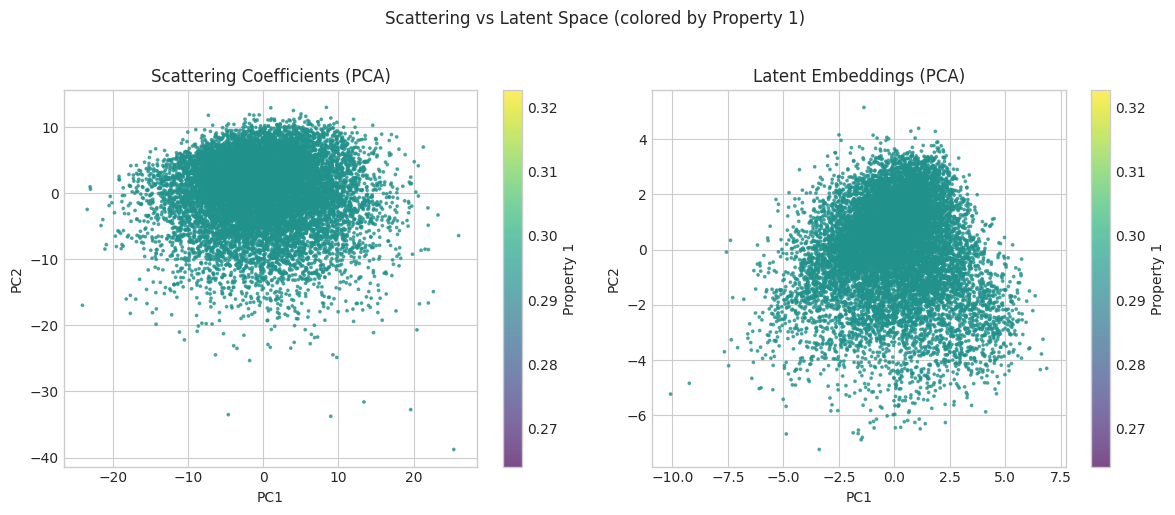

In [18]:
if scattering_coeffs is not None:
    print(f"Scattering coefficients shape: {scattering_coeffs.shape}")
    
    # PCA on scattering coefficients for comparison
    scattering_scaled = StandardScaler().fit_transform(scattering_coeffs)
    pca_scattering = PCA(n_components=2)
    scattering_pca = pca_scattering.fit_transform(scattering_scaled)
    
    print(f"Scattering PCA explained variance: {pca_scattering.explained_variance_ratio_}")
    
    # Compare scattering PCA to latent embeddings
    if len(prop_arrays) > 0:
        color_vals = prop_arrays[0]
        color_label = PROPERTY_NAMES[0]
    else:
        color_vals = np.arange(len(embeddings))
        color_label = 'Sample Index'
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scattering PCA
    sc1 = axes[0].scatter(scattering_pca[:, 0], scattering_pca[:, 1], 
                         c=color_vals, s=3, cmap='viridis', alpha=0.7)
    axes[0].set_title('Scattering Coefficients (PCA)')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    plt.colorbar(sc1, ax=axes[0], label=color_label)
    
    # Latent embeddings PCA
    sc2 = axes[1].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], 
                         c=color_vals, s=3, cmap='viridis', alpha=0.7)
    axes[1].set_title('Latent Embeddings (PCA)')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    plt.colorbar(sc2, ax=axes[1], label=color_label)
    
    plt.suptitle(f'Scattering vs Latent Space (colored by {color_label})', y=1.02)
    plt.tight_layout()
    plt.show()

## 13. Save Figures (Optional)

In [ ]:
# # Set to True to save all figures
# SAVE_FIGURES = False
# OUTPUT_DIR = "latent_space_analysis"

# if SAVE_FIGURES:
#     os.makedirs(OUTPUT_DIR, exist_ok=True)
    
#     # Save PHATE visualizations
#     if embeddings_phate is not None and len(prop_arrays) > 0:
#         for i, prop in enumerate(prop_arrays):
#             prop_name = PROPERTY_NAMES[i].replace(' ', '_')
#             fig = plot_single_embedding(
#                 embeddings_phate, colors=prop,
#                 title=f'PHATE - {PROPERTY_NAMES[i]}',
#                 color_label=PROPERTY_NAMES[i]
#             )
#             fig.savefig(os.path.join(OUTPUT_DIR, f'phate_{prop_name}.png'), 
#                        dpi=300, bbox_inches='tight')
#             plt.close(fig)
    
#     print(f"Figures saved to: {OUTPUT_DIR}")